# Patch Generation for Cluster Quilting

Simulate patchwork missingness on the fully-observed facial landmark dataset.  
Each **patch** is a rectangular block of observed (row, column) indices.  
The generated patches are saved as `.npz` files for downstream use by the Cluster Quilting algorithm.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# Load data
df = pd.read_csv('trialdf_24sessions.csv', index_col=0)
meta_cols = ['valence', 'airstart', 'sucstart', 'ms_id', 'condition', 'inj_site', 'ms_n']
feature_cols = [c for c in df.columns if c not in meta_cols]
df = df.loc[~df['valence'].str.contains('CS')]

# Drop columns with >5% NaN, then drop remaining NaN rows (matches spectral_quilting.ipynb)
thresh = 0.05 * len(df)
feature_cols = [c for c in feature_cols if df[c].isna().sum() <= thresh]
df = df[feature_cols + meta_cols].dropna()

valence = df['valence'].values
X_raw = df[feature_cols].values

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

M, N = X.shape
print(f'Data matrix shape: {M} rows x {N} columns')
print(f'Valence categories: {np.unique(valence)}')

Data matrix shape: 129603 rows x 121 columns
Valence categories: ['Air_US' 'ITI' 'Sucrose_US']


## Patch Generation

Generate rectangular patches that collectively cover all rows and columns, overlap with at least one neighbour, and leave no row fully observed.

In [32]:
def generate_patches(shape, n_patches, min_size, max_size, min_overlap, rng=None):
    """Generate rectangular patches with guaranteed full row/column coverage (no iteration).

    Strategy:
      1. Draw random row block sizes in [min_rows, max_rows], rescale to partition [0, M).
      2. Assign column ranges via sliding window, enforcing min_overlap between consecutive patches.

    Parameters
    ----------
    shape : tuple (M, N)
        Rows and columns of the data matrix.
    n_patches : int
        Number of patches to generate.
    min_size : tuple (min_rows, min_cols)
        Minimum patch dimensions.
    max_size : tuple (max_rows, max_cols)
        Maximum patch dimensions.
    min_overlap : int
        Minimum number of overlapping columns between consecutive patches.
    rng : numpy.random.Generator, optional
        Random number generator.

    Returns
    -------
    list of dict
        Each dict has 'row_idx' and 'col_idx' (numpy arrays).
    """
    if rng is None:
        rng = np.random.default_rng(42)

    M, N = shape
    min_rows, min_cols = min_size
    max_rows, max_cols = max_size

    assert min_overlap < min_cols, "min_overlap must be smaller than min_cols"

    # --- Row partition: random sizes scaled to sum to M ---
    raw_sizes = rng.integers(min_rows, max_rows + 1, size=n_patches).astype(float)
    row_sizes = np.round(raw_sizes / raw_sizes.sum() * M).astype(int)
    row_sizes[-1] = M - row_sizes[:-1].sum()  # fix rounding
    breakpoints = np.concatenate([[0], np.cumsum(row_sizes)])

    # --- Column ranges: sliding window with guaranteed min_overlap ---
    col_starts = []
    col_ends = []
    col_stride = N / n_patches
    col_pos = 0.0
    for i in range(n_patches):
        width = rng.integers(min_cols, max_cols + 1)
        start = max(0, int(col_pos) - rng.integers(min_cols // 2, min_cols))
        end = min(N, start + width)

        # Enforce min_overlap with previous patch
        if i > 0:
            max_start = col_ends[-1] - min_overlap
            if start > max_start:
                start = max(0, max_start)
                end = min(N, start + width)

        # Last patch must reach the end
        if i == n_patches - 1:
            end = N
            start = min(start, N - min_cols)
            if i > 0:
                start = min(start, col_ends[-1] - min_overlap)

        col_starts.append(start)
        col_ends.append(end)
        col_pos += col_stride

    # --- Build patches ---
    patches = []
    for i in range(n_patches):
        row_idx = np.arange(breakpoints[i], breakpoints[i + 1])
        col_idx = np.arange(col_starts[i], col_ends[i])
        patches.append({'row_idx': row_idx, 'col_idx': col_idx})

    return patches

In [33]:
rng = np.random.default_rng(0)
n_patches = 3
min_overlap = 30  # minimum overlapping columns between consecutive patches

patches = generate_patches(
    shape=(M, N),
    n_patches=n_patches,
    min_size=(40, 40),
    max_size=(100, 100),
    min_overlap=min_overlap,
    rng=rng,
)

print(f'Generated {len(patches)} patches (min_overlap={min_overlap})\n')
for i, p in enumerate(patches):
    r, c = p['row_idx'], p['col_idx']
    print(f'  Patch {i}: rows [{r[0]}–{r[-1]}] ({len(r)} rows), '
          f'cols [{c[0]}–{c[-1]}] ({len(c)} cols)')

# Overlap stats
for i in range(len(patches) - 1):
    ci = set(patches[i]['col_idx'].tolist())
    ci1 = set(patches[i + 1]['col_idx'].tolist())
    overlap = ci & ci1
    print(f'  Overlap {i}<->{i+1}: {len(overlap)} shared columns')

Generated 3 patches (min_overlap=30)

  Patch 0: rows [0–49140] (49141 rows), cols [0–55] (56 cols)
  Patch 1: rows [49141–91261] (42121 rows), cols [19–60] (42 cols)
  Patch 2: rows [91262–129602] (38341 rows), cols [31–120] (90 cols)
  Overlap 0<->1: 37 shared columns
  Overlap 1<->2: 30 shared columns


## Observation Pattern Visualization

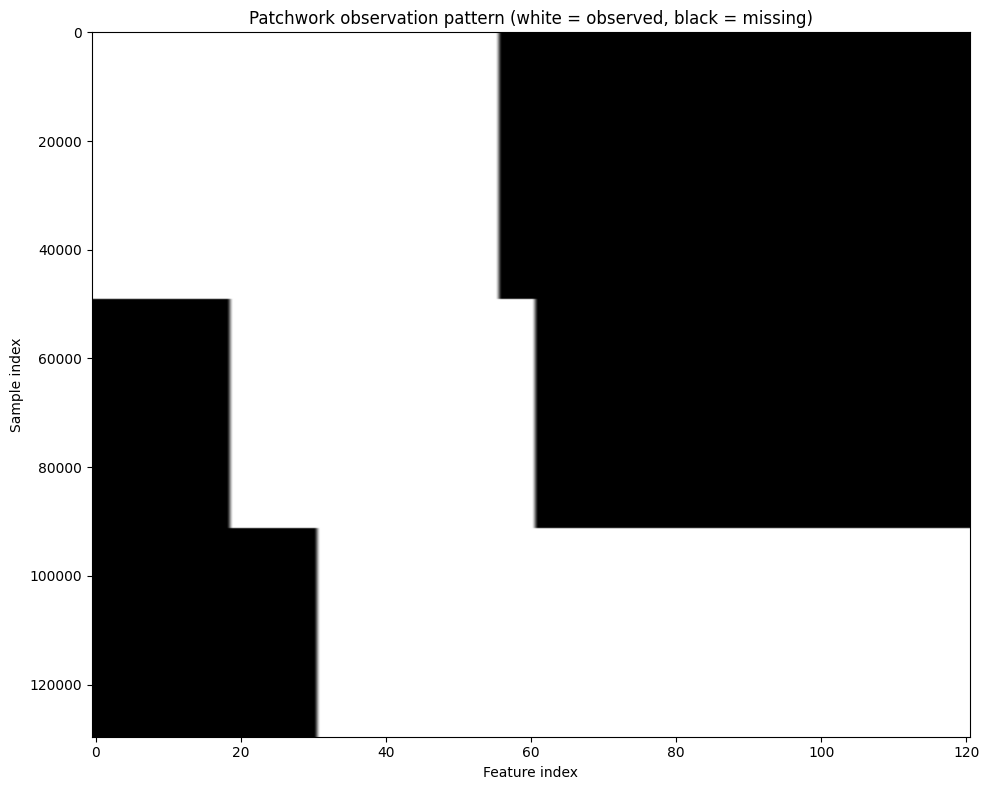

Overall observation rate: 50.8%


In [34]:
# Build binary observation mask
mask = np.zeros((M, N), dtype=np.int8)
for p in patches:
    mask[np.ix_(p['row_idx'], p['col_idx'])] = 1

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(mask, aspect='auto', cmap='Greys_r', vmin=0, vmax=1)
ax.set_title('Patchwork observation pattern (white = observed, black = missing)')
ax.set_xlabel('Feature index')
ax.set_ylabel('Sample index')

plt.tight_layout()
plt.savefig('patchwork_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Overall observation rate: {mask.mean():.1%}')

## Save Patches

Each patch is saved as a separate `.npz` file containing the observed data, row/column indices, feature names, and valence labels.

In [35]:
out_dir = Path('patches')
out_dir.mkdir(exist_ok=True)

for i, p in enumerate(patches):
    row_idx = p['row_idx']
    col_idx = p['col_idx']
    data = X[np.ix_(row_idx, col_idx)]
    fname = out_dir / f'patch_{i:02d}.npz'
    np.savez(
        fname,
        data=data,
        row_idx=row_idx,
        col_idx=col_idx,
        feature_names=np.array([feature_cols[c] for c in col_idx]),
        valence=valence[row_idx],
    )
    print(f'Saved {fname}  shape={data.shape}')

# Quick verification: reload one patch
check = np.load(out_dir / 'patch_00.npz', allow_pickle=True)
print(f'\nVerification — patch_00.npz:')
print(f'  data shape:      {check["data"].shape}')
print(f'  row_idx range:   [{check["row_idx"][0]}–{check["row_idx"][-1]}]')
print(f'  col_idx range:   [{check["col_idx"][0]}–{check["col_idx"][-1]}]')
print(f'  feature_names:   {check["feature_names"][:3]} ...')
print(f'  valence sample:  {check["valence"][:5]}')

Saved patches/patch_00.npz  shape=(49141, 56)
Saved patches/patch_01.npz  shape=(42121, 42)
Saved patches/patch_02.npz  shape=(38341, 90)

Verification — patch_00.npz:
  data shape:      (49141, 56)
  row_idx range:   [0–49140]
  col_idx range:   [0–55]
  feature_names:   ['upper_eye_lower_eye_dist' 'upper_eye_inner_eye_dist'
 'upper_eye_outer_eye_dist'] ...
  valence sample:  ['ITI' 'ITI' 'ITI' 'ITI' 'ITI']
